# ***TITANIC SURVIVAL PREDICTION***


### Name: PRIYOJIT  MONDAL

### Course: Data Science With Python Bootcamp

### Objective:To analyze the Titanic dataset and build a machine learning model to predict whether a passenger survived or not.


## Problem Statement

The Titanic dataset contains information about passengers.
The goal is to analyze the data and build a model to predict survival.

## Tools & Technologies Used:
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

In [ ]:
# Importing Required Libraries
import numpy as np
import pandas as pd

In [ ]:
## Data Collection & Loading .We load the dataset using pandas.
df=pd.read_csv('/content/Day 3  - Day 3 .csv')

### Understanding the Dataset
- Checking first rows
- Checking shape
- Checking columns

In [ ]:
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [ ]:
print(df.tail())

     survived  pclass     sex   age  sibsp  parch   fare embarked   class  \
886         0       2    male  27.0      0      0  13.00        S  Second   
887         1       1  female  19.0      0      0  30.00        S   First   
888         0       3  female   NaN      1      2  23.45        S   Third   
889         1       1    male  26.0      0      0  30.00        C   First   
890         0       3    male  32.0      0      0   7.75        Q   Third   

       who  adult_male deck  embark_town alive  alone  
886    man        True  NaN  Southampton    no   True  
887  woman       False    B  Southampton   yes   True  
888  woman       False  NaN  Southampton    no  False  
889    man        True    C    Cherbourg   yes   True  
890    man        True  NaN   Queenstown    no   True  


In [ ]:
print(df.shape
      )

(891, 15)


In [ ]:
print(df.columns)

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')


### Data Cleaning

Missing values were found in:
- Age
- Deck
- Embarked

We handle missing values to improve model performance.

In [ ]:
print(df.isnull().sum())

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [ ]:
df['age'].fillna(df['age'].mean(),inplace=True)

/tmp/ipykernel_8942/1492264711.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].mean(),inplace=True)


In [ ]:
print(df.isnull().sum())

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In previous we can see there was 177 blank rows now getting 0 blank rows

In [ ]:
df.dropna(inplace=True)

In [ ]:
print(df.isnull().sum())

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64


fillna() replaces missing values (keeps all rows intact).

dropna() removes rows with missing values (data gets reduced).

In [ ]:
print(df[df['age']>30])

     survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
1           1       1  female  38.0      1      0  71.2833        C   First   
3           1       1  female  35.0      1      0  53.1000        S   First   
6           0       1    male  54.0      0      0  51.8625        S   First   
11          1       1  female  58.0      0      0  26.5500        S   First   
21          1       2    male  34.0      0      0  13.0000        S  Second   
..        ...     ...     ...   ...    ...    ...      ...      ...     ...   
862         1       1  female  48.0      0      0  25.9292        S   First   
867         0       1    male  31.0      0      0  50.4958        S   First   
871         1       1  female  47.0      1      1  52.5542        S   First   
872         0       1    male  33.0      0      0   5.0000        S   First   
879         1       1  female  56.0      0      1  83.1583        C   First   

       who  adult_male deck  embark_town alive  alo

In [ ]:
print(df[df['sex']=='female'])

     survived  pclass     sex        age  sibsp  parch      fare embarked  \
1           1       1  female  38.000000      1      0   71.2833        C   
3           1       1  female  35.000000      1      0   53.1000        S   
10          1       3  female   4.000000      1      1   16.7000        S   
11          1       1  female  58.000000      0      0   26.5500        S   
31          1       1  female  29.699118      1      0  146.5208        C   
..        ...     ...     ...        ...    ...    ...       ...      ...   
853         1       1  female  16.000000      0      1   39.4000        S   
862         1       1  female  48.000000      0      0   25.9292        S   
871         1       1  female  47.000000      1      1   52.5542        S   
879         1       1  female  56.000000      0      1   83.1583        C   
887         1       1  female  19.000000      0      0   30.0000        S   

     class    who  adult_male deck  embark_town alive  alone  
1    First  

In [ ]:
print(df.groupby('sex')['survived'].mean())

sex
female    0.936842
male      0.424528
Name: survived, dtype: float64


In [ ]:
df_sorted=df.sort_values(by='age',ascending=True)
print(df_sorted.head(10))

     survived  pclass     sex   age  sibsp  parch      fare embarked   class  \
305         1       1    male  0.92      1      2  151.5500        S   First   
183         1       2    male  1.00      2      1   39.0000        S  Second   
205         0       3  female  2.00      0      1   10.4625        S   Third   
297         0       1  female  2.00      1      2  151.5500        S   First   
340         1       2    male  2.00      1      1   26.0000        S  Second   
193         1       2    male  3.00      1      1   26.0000        S  Second   
445         1       1    male  4.00      0      2   81.8583        S   First   
10          1       3  female  4.00      1      1   16.7000        S   Third   
618         1       2  female  4.00      2      1   39.0000        S  Second   
751         1       3    male  6.00      0      1   12.4750        S   Third   

       who  adult_male deck  embark_town alive  alone  
305  child       False    C  Southampton   yes  False  
183  ch

### Feature Engineering

We create a new feature 'family_size' using:
sibsp + parch

This helps understand group survival patterns.

In [ ]:
df['family_size']=df['sibsp']+df['parch']
print(df.head())

    survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
1          1       1  female  38.0      1      0  71.2833        C  First   
3          1       1  female  35.0      1      0  53.1000        S  First   
6          0       1    male  54.0      0      0  51.8625        S  First   
10         1       3  female   4.0      1      1  16.7000        S  Third   
11         1       1  female  58.0      0      0  26.5500        S  First   

      who  adult_male deck  embark_town alive  alone  family_size  
1   woman       False    C    Cherbourg   yes  False            1  
3   woman       False    C  Southampton   yes  False            1  
6     man        True    E  Southampton    no   True            0  
10  child       False    G  Southampton   yes  False            2  
11  woman       False    C  Southampton   yes   True            0  


In [ ]:
print(df['fare'].max())

512.3292


In [ ]:
df.to_csv("cleaned_Dataset.csv")

In [ ]:
# Importing Required Libraries
import seaborn as sns
import matplotlib.pyplot as plt


survived
1    66.666667
0    33.333333
Name: proportion, dtype: float64


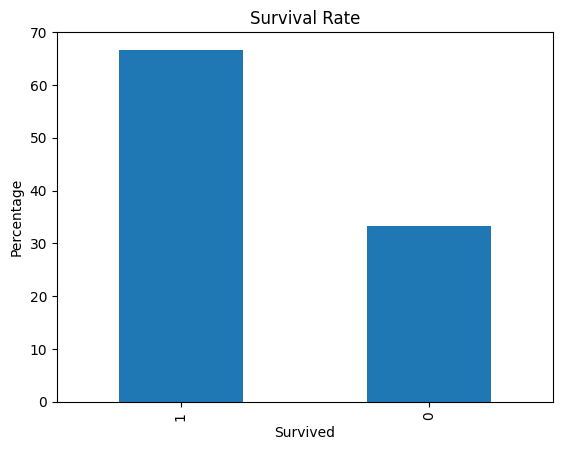

In [ ]:
#Survival Rate
survival_rate= df['survived'].value_counts(normalize=True) * 100
print(survival_rate)
survival_rate.plot(kind='bar')
plt.title('Survival Rate')
plt.xlabel('Survived')
plt.ylabel('Percentage')
plt.ylim(0,70)
plt.show()

Insight:
- Around 66.7% passengers survived while 33.3% did not.
- The dataset shows a higher proportion of survivors than non-survivors.

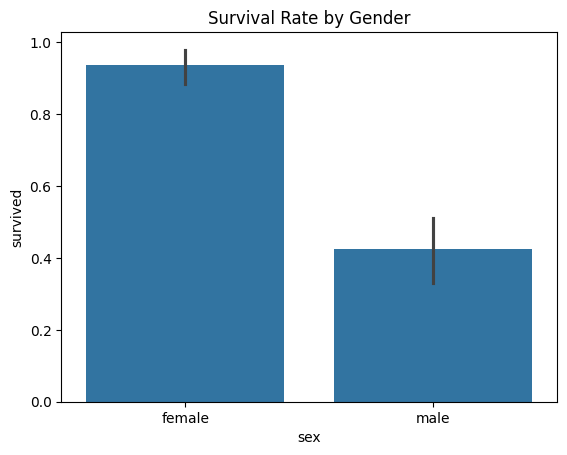

In [ ]:
sns.barplot(x="sex",y="survived",data=df)
plt.title('Survival Rate by Gender')
plt.show()

Insight:
- Female survival rate is extremely high (90%+), while male survival is much lower (40%).
- Gender is one of the strongest factors influencing survival.

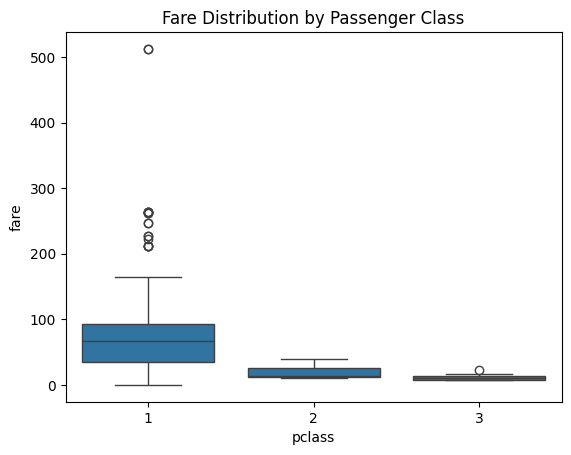

In [ ]:
sns.boxplot(x="pclass",y="fare",data=df)
plt.title('Fare Distribution by Passenger Class')
plt.show()

Insight:
- First-class passengers paid significantly higher fares with wider variation.
- Higher-class passengers had better economic status, which likely improved survival chances.

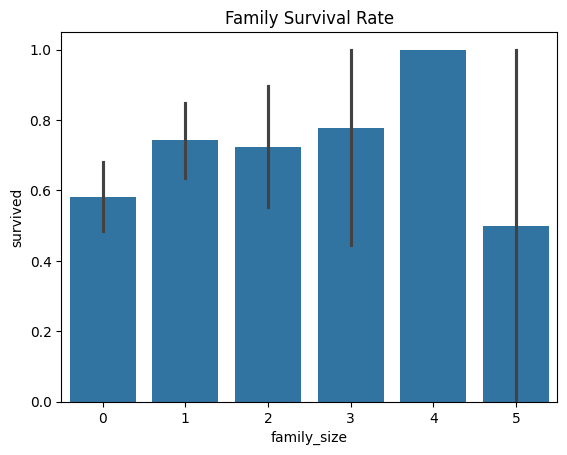

In [ ]:
df ["family_size"]=df["sibsp"]+df["parch"]
sns.barplot(x="family_size",y="survived",data=df)
plt.title("Family Survival Rate")
plt.show()

Insight:
- Passengers with family size around 4 had the highest survival rate.
- Very large families (5+) and individuals alone had lower survival chances.

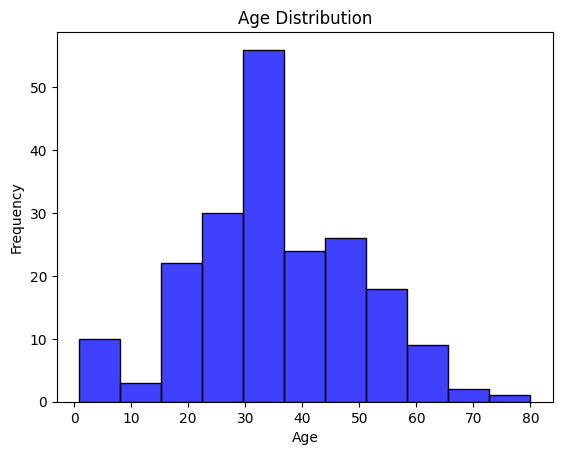

In [ ]:
sns.histplot(df["age"],color="blue")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()


Insight:
- Most passengers were between 30–40 years of age.
- The dataset is dominated by young and middle-aged individuals.

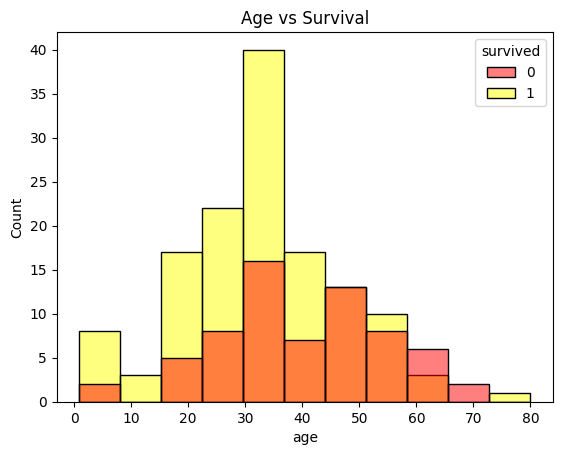

In [ ]:
sns.histplot(data=df,x="age",hue="survived",palette=["red","yellow"]
             )
plt.title("Age vs Survival")
plt.show()


Insight:
- Younger passengers had relatively higher survival chances.
- Survival decreases slightly with increasing age, especially for older passengers.

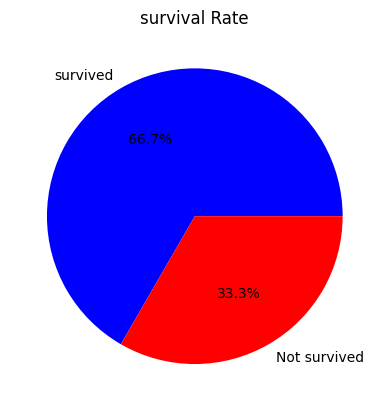

In [ ]:
survival=df["survived"].value_counts()
plt.pie(survival, labels=["survived","Not survived"], autopct='%1.1f%%', colors=["blue","red"])
plt.title("survival Rate")
plt.show()

Insight:
- Majority of passengers survived (66.7%), confirming earlier observations.
- The dataset shows a clear dominance of survival cases.

In [ ]:
survival_percentage=df["survived"].value_counts(normalize=True)*100
print(survival_percentage)

survived
1    66.666667
0    33.333333
Name: proportion, dtype: float64


In [ ]:
dp=pd.read_csv("/content/Day 3  - Day 3 .csv")

### Model Building

We use Logistic Regression to predict survival.

In [ ]:
# Importing Required Libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
df["embarked"] = df["embarked"].fillna("s")

In [ ]:
df["deck"].fillna("Unknown",inplace=True)

/tmp/ipykernel_8942/4037492315.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["deck"].fillna("Unknown",inplace=True)


In [ ]:
df.drop(["class","who","adult_male","deck","embark_town","alive"],axis=1,inplace=True)

In [ ]:
df["sex"]=df["sex"].astype(str).str.lower().map({"male":0,"female":1})
df["embarked"]=df["embarked"].astype(str).str.lower().map({"s":0,"c":1,"q":2})
df["alone"]=df["alone"].map({True:1,False:0})
df.fillna(0,inplace=True)

In [ ]:
x=df.drop("survived",axis=1)
y=df["survived"]

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
model=LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

Accuracy: 0.8049
Confusion Matrix:
[[ 2  5]
 [ 3 31]]


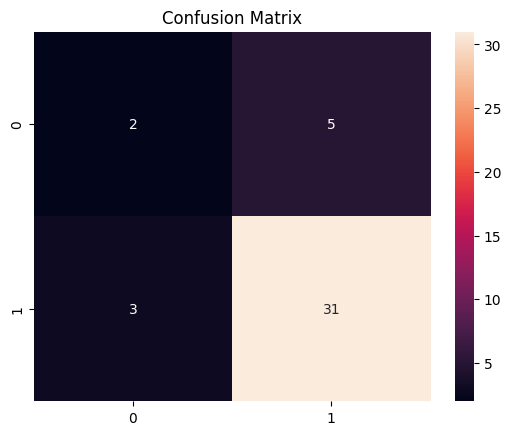

In [ ]:
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Confusion Matrix:\n{conf_matrix}")
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt="d")
plt.title("Confusion Matrix")
plt.show()

## Model Evaluation

Accuracy: 80.49%

The model performs well, correctly predicting most of the cases.

### Confusion Matrix Interpretation:
- True Positives (31): Correctly predicted survived passengers
- True Negatives (2): Correctly predicted non-survivors
- False Positives (5): Predicted survived but actually did not
- False Negatives (3): Predicted not survived but actually survived

### Limitations
- Model shows slight bias toward survival prediction
- Dataset imbalance affects accuracy

### Analysis:

- The model is better at predicting survivors than non-survivors.
- Higher True Positives (31) shows strong detection of survival cases.
- Some errors exist (False Positives & False Negatives), meaning predictions are not perfect.
- Dataset imbalance may affect performance.

# Conclusion

This project successfully applied data science techniques to analyze the Titanic dataset and predict survival outcomes.

The analysis revealed that gender, passenger class, and family size played a crucial role in survival. Females and first-class passengers had a higher probability of survival.

The Logistic Regression model achieved around 80% accuracy, indicating good performance. However, the model showed a slight bias toward predicting survivors, suggesting the need for further optimization.

This project highlights the importance of data preprocessing, visualization, and model evaluation in building effective machine learning solutions.